# Exploración de datos PAES 2026 — CLEC_MAX

Continuación de `01_exploracion_datos.ipynb`. En ese notebook, el análisis de `CLEC_REG_ACTUAL` cerró con una nota pendiente: evaluar si `CLEC_MAX` — y en conjunto con `MATE1_MAX` y `MATE2_MAX` — podrían ser las variables definitivas para el análisis final del proyecto, dado que `CLEC_REG_ACTUAL` depende de si el estudiante rindió específicamente el proceso 2026, mientras que `CLEC_MAX` recoge el mejor puntaje entre todas las rendiciones disponibles.

Este notebook aborda **exclusivamente `CLEC_MAX`**, con foco descriptivo:

- tipo de dato
- valores nulos y valores en cero (distinción explícita entre ambos)
- estadísticos de tendencia central y dispersión
- distribución por bandas de puntaje

> **Nota al margen:** la decisión sobre cómo tratar los valores en cero (posible no-rendición de la prueba, más que un desempeño real) **no se resuelve en este notebook**. Se documenta como hallazgo y se deja pendiente para una etapa posterior, una vez consensuado el criterio con el equipo — siguiendo la misma lógica de "describir primero, decidir después" aplicada en `01_exploracion_datos.ipynb`.

## Entorno y carga de datos

In [1]:
# Mismas rutas y misma fuente de datos utilizadas en 01_exploracion_datos.ipynb
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RAW_DIR = DIRECTORIO_RAIZ / "data" / "raw"

In [2]:
# Carga del conjunto Inscritos y Puntajes (separador ';' y decimal ',', igual que en 01_exploracion_datos.ipynb)
RUTA_INSCRITOS = RAW_DIR / "PAES-2026-Inscritos-Puntajes" / "A_INSCRITOS_PUNTAJES_PAES_2026_PUB_MRUN.csv"

inscritos = pd.read_csv(RUTA_INSCRITOS, sep=";", decimal=",", low_memory=False)
inscritos.shape  # (filas, columnas): confirma que cargamos las mismas 320.087 observaciones que en 01_exploracion_datos.ipynb

(320087, 131)

## Foco de esta entrega: `CLEC_MAX`

Según la ficha de metadatos (`ER_Alumnos_2026_PAES_MRUN_A_INSCRITOS_PUNTAJES.pdf`), `CLEC_MAX` corresponde al **puntaje máximo obtenido entre todas las Pruebas de Competencia Lectora rendidas**, a diferencia de `CLEC_REG_ACTUAL`, que refleja únicamente el resultado del proceso regular 2026.

In [3]:
# Guardamos la columna en una variable aparte para no repetir inscritos["CLEC_MAX"] en cada celda
CLEC_MAX_col = inscritos["CLEC_MAX"]

# Primer chequeo obligatorio antes de calcular cualquier estadistico: el tipo de dato
# (en 01_exploracion_datos.ipynb, CLEC_REG_ACTUAL resulto ser "str" pese a ser una variable numerica segun el PDF)
CLEC_MAX_col.dtype

dtype('int64')

> **Nota al margen:** a diferencia de `CLEC_REG_ACTUAL` (que en `01_exploracion_datos.ipynb` se detectó como tipo `str` y requirió conversión con `pd.to_numeric(errors="coerce")`), `CLEC_MAX` ya es reconocida por pandas como numérica (`int64`). Esto es en sí un hallazgo relevante: en pandas, una columna `int64` no admite valores `NaN` — de existir alguno, pandas habría forzado el tipo a `float64`. Es un indicio fuerte de que la columna no tiene datos faltantes, lo cual confirmamos explícitamente a continuación en lugar de darlo por sentado.

## Nulos vs. ceros: una distinción que hay que hacer explícita

In [4]:
# n_total: cantidad de filas del dataset completo, para poder calcular porcentajes
n_total = len(inscritos)

# n_nulos: cuenta valores NaN (dato inexistente)
n_nulos = CLEC_MAX_col.isna().sum()

# n_ceros: cuenta valores == 0 (dato existe, pero su valor es cero; distinto de un NaN)
n_ceros = (CLEC_MAX_col == 0).sum()

# n_validos: todo lo que es un puntaje mayor a cero, es decir, un puntaje "interpretable" sin ambiguedad
n_validos = (CLEC_MAX_col > 0).sum()

# Armamos una tabla resumen para visualizar los tres conteos y sus porcentajes de una sola vez
resumen_clec_max = pd.DataFrame({
    "Cantidad": [n_nulos, n_ceros, n_validos],
    "% del total": [
        round(n_nulos / n_total * 100, 2),
        round(n_ceros / n_total * 100, 2),
        round(n_validos / n_total * 100, 2),
    ]
}, index=["Nulos (NaN)", "En cero", "Puntaje > 0"])

resumen_clec_max

,Cantidad,% del total
Nulos (NaN),0,0.00
En cero,43126,13.47
Puntaje > 0,276961,86.53


Se confirma que `CLEC_MAX` **no tiene valores nulos** (0,00%). Sin embargo, **un 13,47% de las observaciones (43.126 casos) registra un valor de cero**. Dado que la Prueba de Competencia Lectora es de carácter obligatorio en el proceso de admisión, este porcentaje llama la atención: no es evidente, a partir de este dato por sí solo, si corresponde a un desempeño real de 0 puntos o si encubre una no-rendición de la prueba por parte del estudiante.

**Esta pregunta no se responde en este notebook.** Queda documentada como decisión pendiente para una etapa posterior del análisis (ver síntesis final).

### Contraste con `CLEC_REG_ACTUAL`

Para dimensionar cuánto "rescata" `CLEC_MAX` frente a la variable de registro actual, se compara contra `CLEC_REG_ACTUAL` (convertida a numérica, ya que en `01_exploracion_datos.ipynb` se detectó como `str`).

In [5]:
# CLEC_REG_ACTUAL llega como texto (str), igual que se detecto en 01_exploracion_datos.ipynb.
# pd.to_numeric con errors="coerce" convierte lo que puede a numero, y transforma en NaN todo lo que no puede.
reg_num = pd.to_numeric(inscritos["CLEC_REG_ACTUAL"], errors="coerce")

# Casos "rescatados": el estudiante NO tiene dato en el proceso regular actual (quedo NaN),
# pero SI tiene un puntaje mayor a 0 en CLEC_MAX (lo rindio en otro proceso/fecha)
rescatados = ((reg_num.isna()) & (CLEC_MAX_col > 0)).sum()

print("Nulos en CLEC_REG_ACTUAL:", reg_num.isna().sum(), f"({reg_num.isna().sum()/n_total*100:.2f}%)")
print("Ceros en CLEC_REG_ACTUAL:", (reg_num == 0).sum(), f"({(reg_num==0).sum()/n_total*100:.2f}%)")
print("Rescatados por CLEC_MAX: ", rescatados, f"({rescatados/n_total*100:.2f}%)")

Nulos en CLEC_REG_ACTUAL: 19496 (6.09%)
Ceros en CLEC_REG_ACTUAL: 49518 (15.47%)
Rescatados por CLEC_MAX:  18304 (5.72%)

> **Nota al margen:** `CLEC_MAX` rescata un **5,72%** de estudiantes que `CLEC_REG_ACTUAL` pierde por nulos (rindieron la prueba en otro proceso o fecha distinta a la actual). Esta es la evidencia cuantitativa que respalda usar `CLEC_MAX` como variable "definitiva" en vez de `CLEC_REG_ACTUAL`, tal como se planteaba en el cierre de `01_exploracion_datos.ipynb`.

## Estadísticos descriptivos

In [6]:
# Tendencia central (media, mediana, moda) y dispersion (desviacion estandar),
# mismo tipo de resumen que se aplico a CLEC_REG_ACTUAL en 01_exploracion_datos.ipynb
print("Media:   ", CLEC_MAX_col.mean().round(1))
print("Mediana: ", CLEC_MAX_col.median().round(1))
print("Moda:    ", CLEC_MAX_col.mode().iloc[0], f"(n={n_ceros})")  # se indica cuantas veces se repite la moda
print("Desv.Est:", CLEC_MAX_col.std().round(1))

Media:    532.5
Mediana:  583.0
Moda:     0 (n=43126)
Desv.Est: 240.5

> **Nota al margen:** la moda coincide exactamente con la cantidad de ceros detectada en el paso anterior — es decir, el valor "más frecuente" de la distribución es justamente el valor bajo sospecha de no ser un puntaje real. Esto no invalida la media ni la mediana (calculadas sobre el total de observaciones), pero sí refuerza que cualquier interpretación de "desempeño promedio" debería considerar excluir o tratar aparte estos casos.

In [7]:
# describe() entrega de una vez count, media, desv.est. y los 4 cuartiles (min, 25%, 50%, 75%, max)
CLEC_MAX_col.describe().round(1)

count    320087.0
mean        532.5
std         240.5
min           0.0
25%         477.0
50%         583.0
75%         690.0
max        1000.0
Name: CLEC_MAX, dtype: float64

## Distribución por bandas de puntaje

In [8]:
# Agrupamos los puntajes en bandas de 100 puntos (0-100, 100-200, ..., 900-1000)
# value_counts(bins=...) hace el corte y cuenta automaticamente cuantas observaciones caen en cada banda
tabla_bandas = inscritos["CLEC_MAX"].value_counts(bins=range(0, 1100, 100), sort=False).reset_index()
tabla_bandas.columns = ["Banda de puntaje", "Observaciones"]
tabla_bandas["Porcentaje"] = (tabla_bandas["Observaciones"] / n_total * 100).round(2)
tabla_bandas

Banda de puntaje,Observaciones,Porcentaje
"(-0.001, 100.0]",43165,13.49
"(100.0, 200.0]",14,0.00
"(200.0, 300.0]",261,0.08
"(300.0, 400.0]",8951,2.80
"(400.0, 500.0]",52643,16.45
"(500.0, 600.0]",76401,23.87
"(600.0, 700.0]",71811,22.43
"(700.0, 800.0]",43783,13.68
"(800.0, 900.0]",20421,6.38
"(900.0, 1000.0]",2637,0.82


> **Nota al margen:** la primera banda (0-100) agrupa 43.165 observaciones, una cifra levemente superior a los 43.126 ceros exactos identificados antes — la diferencia (39 casos) corresponde a estudiantes con puntajes reales muy bajos (entre 1 y 100 puntos), y no a casos de no-rendición. Al graficar más abajo con `plt.hist` (bins por defecto, sin el ajuste de borde `-0.001` que aplica `value_counts`), este primer bloque coincide exactamente con los 43.126 ceros.

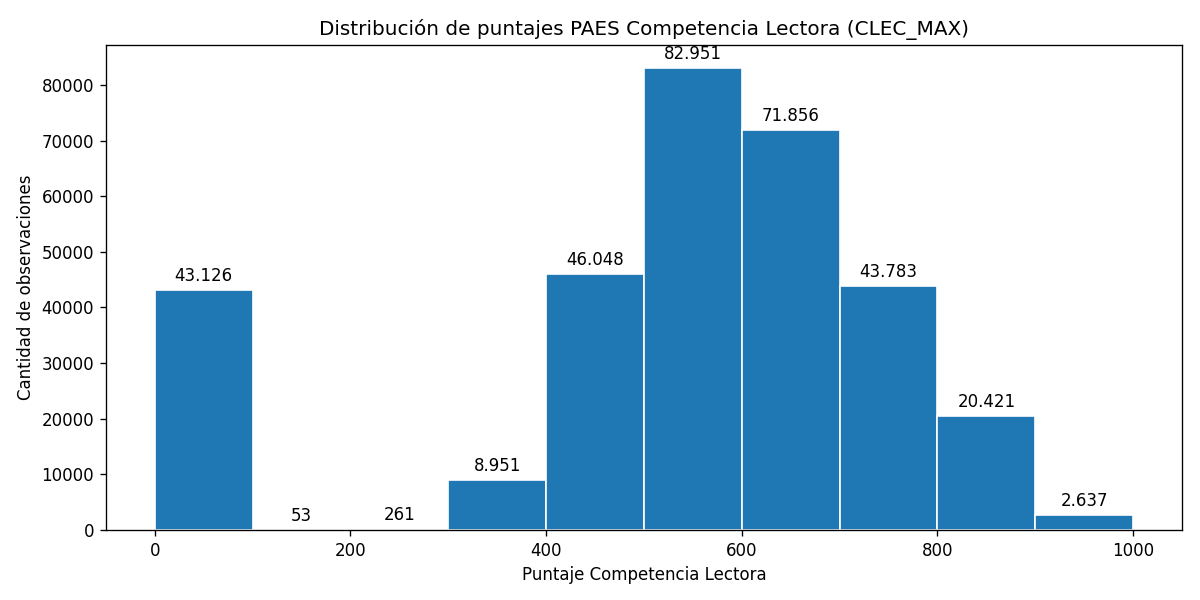

In [9]:
# Mismo grafico que value_counts pero en formato histograma, para visualizar la forma de la distribucion
plt.figure(figsize=(10, 5))

# bins=range(0, 1100, 100) define los cortes: 0, 100, 200, ..., 1000 (10 barras de 100 puntos cada una)
conteos, bordes, barras = plt.hist(
    inscritos["CLEC_MAX"],
    bins=range(0, 1100, 100),
    color="#1f77b4",
    edgecolor="white"
)

plt.xlabel("Puntaje Competencia Lectora")
plt.ylabel("Cantidad de observaciones")
plt.title("Distribución de puntajes PAES Competencia Lectora (CLEC_MAX)")

# bar_label agrega el numero exacto de observaciones encima de cada barra (mas facil de leer que solo el eje Y)
plt.bar_label(
    barras,
    labels=[f"{int(x):,}".replace(",", ".") for x in conteos],  # formatea con punto de mil (estilo chileno)
    padding=3
)
plt.show()

## Síntesis y decisión pendiente

- `CLEC_MAX` **no presenta valores nulos** (0,00%).
- **13,47% de las observaciones (43.126 casos)** registra un valor de cero, posiblemente asociado a no-rendición de la prueba más que a un desempeño real de 0 puntos.
- `CLEC_MAX` rescata un **5,72%** de casos que `CLEC_REG_ACTUAL` pierde por nulos, lo que respalda usarla como variable más "definitiva" para el análisis final.
- El 86,53% restante se distribuye de forma razonablemente simétrica entre 400 y 800 puntos, con media 532,5 y mediana 583,0 (desviación estándar 240,5).

**To Do equipo:** definir el criterio de tratamiento para los valores en cero (excluir, imputar, o modelar como categoría "no rindió" separada del puntaje) antes de usar `CLEC_MAX` en el análisis final. Se replicó este mismo procedimiento para `MATE1_MAX` (`03_exploracion_mate1_max.ipynb`) y `MATE2_MAX` (`04_exploracion_mate2_max.ipynb`), donde esta última mostró una proporción de ceros sustancialmente mayor, posiblemente por tratarse de una prueba de carácter optativo dentro del proceso de admisión.